# Kappa (κ) Estimation - Order Arrival Rate Calibration

**Purpose:** Estimate the order arrival intensity κ per symbol from real tick data.  
**Current state:** κ = 1.5 hardcoded for all symbols (suboptimal).  
**Goal:** Symbol-specific κ that reflects actual order flow, improving A-S spread sizing.

## Theory
In the Avellaneda-Stoikov model, order arrivals follow a Poisson process:  
$$\lambda^{b/a}(\delta) = A \cdot e^{-\kappa \delta}$$

Where:
- $\lambda$ = arrival rate of buy/sell limit orders
- $\delta$ = distance of your quote from mid price
- $A$ = baseline arrival intensity
- $\kappa$ = sensitivity of arrivals to distance (higher κ = orders dry up quickly as you move away from mid)

**High κ** → arrivals drop off fast with distance → quote tight or get no fills  
**Low κ** → arrivals are distance-insensitive → can quote wider and still get filled

## Data
GCS path: `gs://hedge-fund-494103-marketdata/processed/features/{symbol}/{date}.parquet`  
Key columns: `ts_sec`, `ts_ist`, `close` (mid proxy), `spread_mean`, `realized_vol_60s`, `imbalance_last`

---

## 0. Imports & Config

In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gcsfs
from matplotlib.patches import Patch
from scipy.optimize import curve_fit
from scipy.stats import expon, kstest
from datetime import datetime

warnings.filterwarnings('ignore')
plt.style.use('dark_background')

# ── Config ────────────────────────────────────────────────────────────────────
GCP_PROJECT  = 'hedge-fund-494103'
GCS_BUCKET   = 'hedge-fund-494103-marketdata'
GCS_PREFIX   = 'processed/features'
FINDINGS_DIR = '../findings'

SYMBOLS = [
    'CHOLAFIN26MAYFUT',
    'ADANIPORTS26MAYFUT',
    'DRREDDY26MAYFUT',
    'ADANIENT26MAYFUT',
    'HAVELLS26MAYFUT',
    'JSWSTEEL26MAYFUT',
    'RELIANCE26MAYFUT',
]

DATES = ['2026-05-13', '2026-05-14', '2026-05-15']

os.makedirs(FINDINGS_DIR, exist_ok=True)
print('Config loaded. GCS prefix:', f"{GCS_BUCKET}/{GCS_PREFIX}")

c:\projects\quant-fund\venv\lib\site-packages\google\api_core\_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.9) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
c:\projects\quant-fund\venv\lib\site-packages\google\api_core\_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.9) which Google will stop supporting in new releases of google.cloud.storage_control_v2 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.storage_control_v2 past that date.
  warnings.warn(message, FutureWarning)


Config loaded. GCS prefix: hedge-fund-494103-marketdata/processed/features


## 1. Inspect Schema (run once)

In [2]:
fs = gcsfs.GCSFileSystem(project=GCP_PROJECT)

# Find most recent available file for first symbol
sample_sym = SYMBOLS[0]
found = None
for date in reversed(DATES):
    path = f"{GCS_BUCKET}/{GCS_PREFIX}/{sample_sym}/{date}.parquet"
    if fs.exists(path):
        found = path
        break

if found:
    df_sample = pd.read_parquet(f"gs://{found}")
    print(f'File: {found}')
    print(f'Rows: {len(df_sample):,}')
    print(f'\nColumns ({len(df_sample.columns)}):')
    for col in df_sample.columns:
        print(f'  {col:35s} {str(df_sample[col].dtype):12s}  sample={df_sample[col].iloc[0]}')
else:
    print(f'No files found for {sample_sym} on dates {DATES}')
    print('\nSearching bucket for any available files...')
    available = fs.glob(f"{GCS_BUCKET}/{GCS_PREFIX}/{sample_sym}/*.parquet")
    print('Available:', available[:5])

File: hedge-fund-494103-marketdata/processed/features/CHOLAFIN26MAYFUT/2026-05-15.parquet
Rows: 19,156

Columns (54):
  symbol                              object        sample=CHOLAFIN26MAYFUT
  ts_sec                              int64         sample=1778807443
  open                                float64       sample=1567.3
  high                                float64       sample=1567.3
  low                                 float64       sample=1567.3
  close                               float64       sample=1567.3
  volume_delta                        int64         sample=0
  volume_cumulative                   int64         sample=0
  tick_count                          int64         sample=1
  vwap                                float64       sample=0.0
  oi                                  int64         sample=17698750
  spread_mean                         float64       sample=0.0
  spread_max                          int64         sample=0
  spread_bps                      

## 2. Load Data from GCS

In [3]:
def load_symbol_data(symbol: str, dates: list, fs) -> pd.DataFrame:
    """Load processed feature parquets. Path: processed/features/{symbol}/{date}.parquet"""
    frames = []
    for date in dates:
        path = f"{GCS_BUCKET}/{GCS_PREFIX}/{symbol}/{date}.parquet"
        if not fs.exists(path):
            print(f'  [MISS] {symbol} / {date}')
            continue
        df = pd.read_parquet(f"gs://{path}")
        df['date'] = date
        frames.append(df)
        print(f'  [OK]   {symbol} / {date} — {len(df):,} bars')

    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True).sort_values('ts_sec').reset_index(drop=True)


symbol_data = {}
for sym in SYMBOLS:
    print(f'Loading {sym}...')
    df = load_symbol_data(sym, DATES, fs)
    if not df.empty:
        symbol_data[sym] = df

print(f'\nLoaded {len(symbol_data)}/{len(SYMBOLS)} symbols')

Loading CHOLAFIN26MAYFUT...
  [OK]   CHOLAFIN26MAYFUT / 2026-05-13 — 18,244 bars
  [OK]   CHOLAFIN26MAYFUT / 2026-05-14 — 17,959 bars
  [OK]   CHOLAFIN26MAYFUT / 2026-05-15 — 19,156 bars
Loading ADANIPORTS26MAYFUT...
  [OK]   ADANIPORTS26MAYFUT / 2026-05-13 — 19,859 bars
  [OK]   ADANIPORTS26MAYFUT / 2026-05-14 — 19,188 bars
  [OK]   ADANIPORTS26MAYFUT / 2026-05-15 — 19,876 bars
Loading DRREDDY26MAYFUT...
  [OK]   DRREDDY26MAYFUT / 2026-05-13 — 20,205 bars
  [OK]   DRREDDY26MAYFUT / 2026-05-14 — 11,551 bars
  [OK]   DRREDDY26MAYFUT / 2026-05-15 — 11,579 bars
Loading ADANIENT26MAYFUT...
  [OK]   ADANIENT26MAYFUT / 2026-05-13 — 17,422 bars
  [OK]   ADANIENT26MAYFUT / 2026-05-14 — 20,602 bars
  [OK]   ADANIENT26MAYFUT / 2026-05-15 — 20,682 bars
Loading HAVELLS26MAYFUT...
  [OK]   HAVELLS26MAYFUT / 2026-05-13 — 18,068 bars
  [OK]   HAVELLS26MAYFUT / 2026-05-14 — 17,384 bars
  [OK]   HAVELLS26MAYFUT / 2026-05-15 — 18,390 bars
Loading JSWSTEEL26MAYFUT...
  [OK]   JSWSTEEL26MAYFUT / 2026-05-1

## 3. Prepare Features

In [4]:
def prepare_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['mid']         = df['close']                          # 1s bar close as mid proxy
    df['half_spread'] = df['spread_mean'] / 2                # δ = half the natural spread
    df['spread_bps']  = df['spread_mean'] / df['mid'] * 10000
    # IST time-of-day in seconds: UTC epoch + 5:30 offset
    df['ist_tod_sec'] = (df['ts_sec'] + 19800) % 86400
    df['ist_hhmm']    = df['ist_tod_sec'].apply(
        lambda s: f"{int(s)//3600:02d}:{(int(s)%3600)//60:02d}"
    )
    return df


for sym in list(symbol_data.keys()):
    try:
        symbol_data[sym] = prepare_features(symbol_data[sym])
        df = symbol_data[sym]
        print(f"{sym:30s}  mid={df['mid'].mean():.2f}  "
              f"spread={df['spread_mean'].mean():.4f}  "
              f"bps={df['spread_bps'].mean():.2f}  bars={len(df):,}")
    except Exception as e:
        print(f'{sym}: ERROR — {e}')
        print('  Columns:', symbol_data[sym].columns.tolist())

CHOLAFIN26MAYFUT                mid=1572.66  spread=1.1626  bps=7.40  bars=55,359
ADANIPORTS26MAYFUT              mid=1770.45  spread=0.5006  bps=2.83  bars=58,923
DRREDDY26MAYFUT                 mid=1289.83  spread=-0.4202  bps=-3.40  bars=43,335
ADANIENT26MAYFUT                mid=2638.97  spread=0.3774  bps=1.52  bars=58,706
HAVELLS26MAYFUT                 mid=1201.62  spread=1.0262  bps=8.54  bars=53,842
JSWSTEEL26MAYFUT                mid=1290.85  spread=0.1869  bps=1.48  bars=35,363
RELIANCE26MAYFUT                mid=1360.33  spread=-0.0854  bps=-0.61  bars=57,077


## 4. Inter-Arrival Time Analysis

1-second bars: consecutive `ts_sec` gaps tell us how active each symbol is.  
KS test checks whether arrivals are Poisson (exponential inter-arrival times).

In [5]:
def compute_interarrival_stats(df: pd.DataFrame, symbol: str) -> dict:
    ts  = df['ts_sec'].sort_values()
    iat = ts.diff().dropna()
    iat = iat[(iat > 0) & (iat < 60)]

    total_time = float(ts.iloc[-1] - ts.iloc[0])
    lambda_eff = len(ts) / total_time if total_time > 0 else 0

    loc, scale = expon.fit(iat, floc=0)
    ks_stat, ks_pval = kstest(iat, 'expon', args=(0, scale))

    return {
        'symbol':         symbol,
        'n_bars':         len(ts),
        'mean_iat_sec':   float(iat.mean()),
        'lambda_per_sec': float(lambda_eff),
        'lambda_per_min': float(lambda_eff * 60),
        'ks_stat':        float(ks_stat),
        'ks_pval':        float(ks_pval),
        'is_poisson':     bool(ks_pval > 0.05),
        'iat_series':     iat,
    }


iat_stats = {}
print(f"{'Symbol':30s} {'λ/min':>8} {'mean_iat':>10} {'Poisson?':>10} {'p-val':>8}")
print('-' * 73)
for sym, df in symbol_data.items():
    s = compute_interarrival_stats(df, sym)
    iat_stats[sym] = s
    print(f"{sym:30s} {s['lambda_per_min']:>8.1f} {s['mean_iat_sec']:>10.3f}s "
          f"{'YES' if s['is_poisson'] else 'NO ':>10} {s['ks_pval']:>8.4f}")

Symbol                            λ/min   mean_iat   Poisson?    p-val
-------------------------------------------------------------------------
CHOLAFIN26MAYFUT                   15.8      1.242s        NO    0.0000
ADANIPORTS26MAYFUT                 16.8      1.169s        NO    0.0000
DRREDDY26MAYFUT                    12.4      1.588s        NO    0.0000
ADANIENT26MAYFUT                   16.8      1.175s        NO    0.0000
HAVELLS26MAYFUT                    15.4      1.277s        NO    0.0000
JSWSTEEL26MAYFUT                   10.1      1.944s        NO    0.0000
RELIANCE26MAYFUT                   16.3      1.208s        NO    0.0000


## 5. Estimate κ

In [6]:
def estimate_kappa(df: pd.DataFrame, n_bins: int = 20) -> dict:
    delta = df['half_spread'].dropna()
    delta = delta[(delta > 0) & (delta < delta.quantile(0.99))]

    if len(delta) < 20:
        return {'kappa': np.nan, 'A': np.nan, 'r2': np.nan}

    bins   = np.linspace(delta.min(), delta.quantile(0.95), n_bins + 1)
    labels = (bins[:-1] + bins[1:]) / 2
    counts = np.array([((delta >= bins[i]) & (delta < bins[i+1])).sum()
                       for i in range(n_bins)], dtype=float)

    total_time   = float(df['ts_sec'].iloc[-1] - df['ts_sec'].iloc[0])
    arrival_rate = counts / total_time if total_time > 0 else counts

    mask = arrival_rate > 0
    x, y = labels[mask], arrival_rate[mask]
    if len(x) < 4:
        return {'kappa': np.nan, 'A': np.nan, 'r2': np.nan}

    def model(d, A, k): return A * np.exp(-k * d)

    try:
        popt, _ = curve_fit(model, x, y, p0=[y[0], 1.5], maxfev=5000,
                            bounds=([0, 0.01], [np.inf, 50]))
        A_fit, kappa_fit = popt
        y_pred = model(x, *popt)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2     = float(1 - ss_res / ss_tot) if ss_tot > 0 else 0.0
        return {'kappa': round(float(kappa_fit), 4), 'A': round(float(A_fit), 8),
                'r2': round(r2, 4), 'x_bins': x, 'y_rates': y, 'y_fit': model(x, *popt)}
    except Exception as e:
        print(f'  curve_fit failed ({sym}): {e}')
        return {'kappa': np.nan, 'A': np.nan, 'r2': np.nan}


kappa_results = {}
print(f"{'Symbol':30s} {'κ estimated':>13} {'R²':>6} {'vs 1.5 (Δ)':>12}")
print('-' * 68)
for sym, df in symbol_data.items():
    res = estimate_kappa(df)
    kappa_results[sym] = res
    k = res['kappa']
    if not (k is None or (isinstance(k, float) and np.isnan(k))):
        diff = k - 1.5
        tag  = f"{'▲' if diff > 0 else '▼'} {abs(diff):.3f}"
    else:
        tag = 'N/A'
    print(f"{sym:30s} {str(k):>13} {str(res['r2']):>6} {tag:>12}")

Symbol                           κ estimated     R²   vs 1.5 (Δ)
--------------------------------------------------------------------
CHOLAFIN26MAYFUT                      1.4953 0.0166      ▼ 0.005
ADANIPORTS26MAYFUT                    0.2564 -0.0001      ▼ 1.244
DRREDDY26MAYFUT                       1.4779 0.0164      ▼ 0.022
ADANIENT26MAYFUT                        0.01 -0.0002      ▼ 1.490
HAVELLS26MAYFUT                          nan    nan          N/A
JSWSTEEL26MAYFUT                      1.3614 -0.0219      ▼ 0.139
RELIANCE26MAYFUT                      1.2414 -0.0123      ▼ 0.259


## 6. Visualize κ Fits

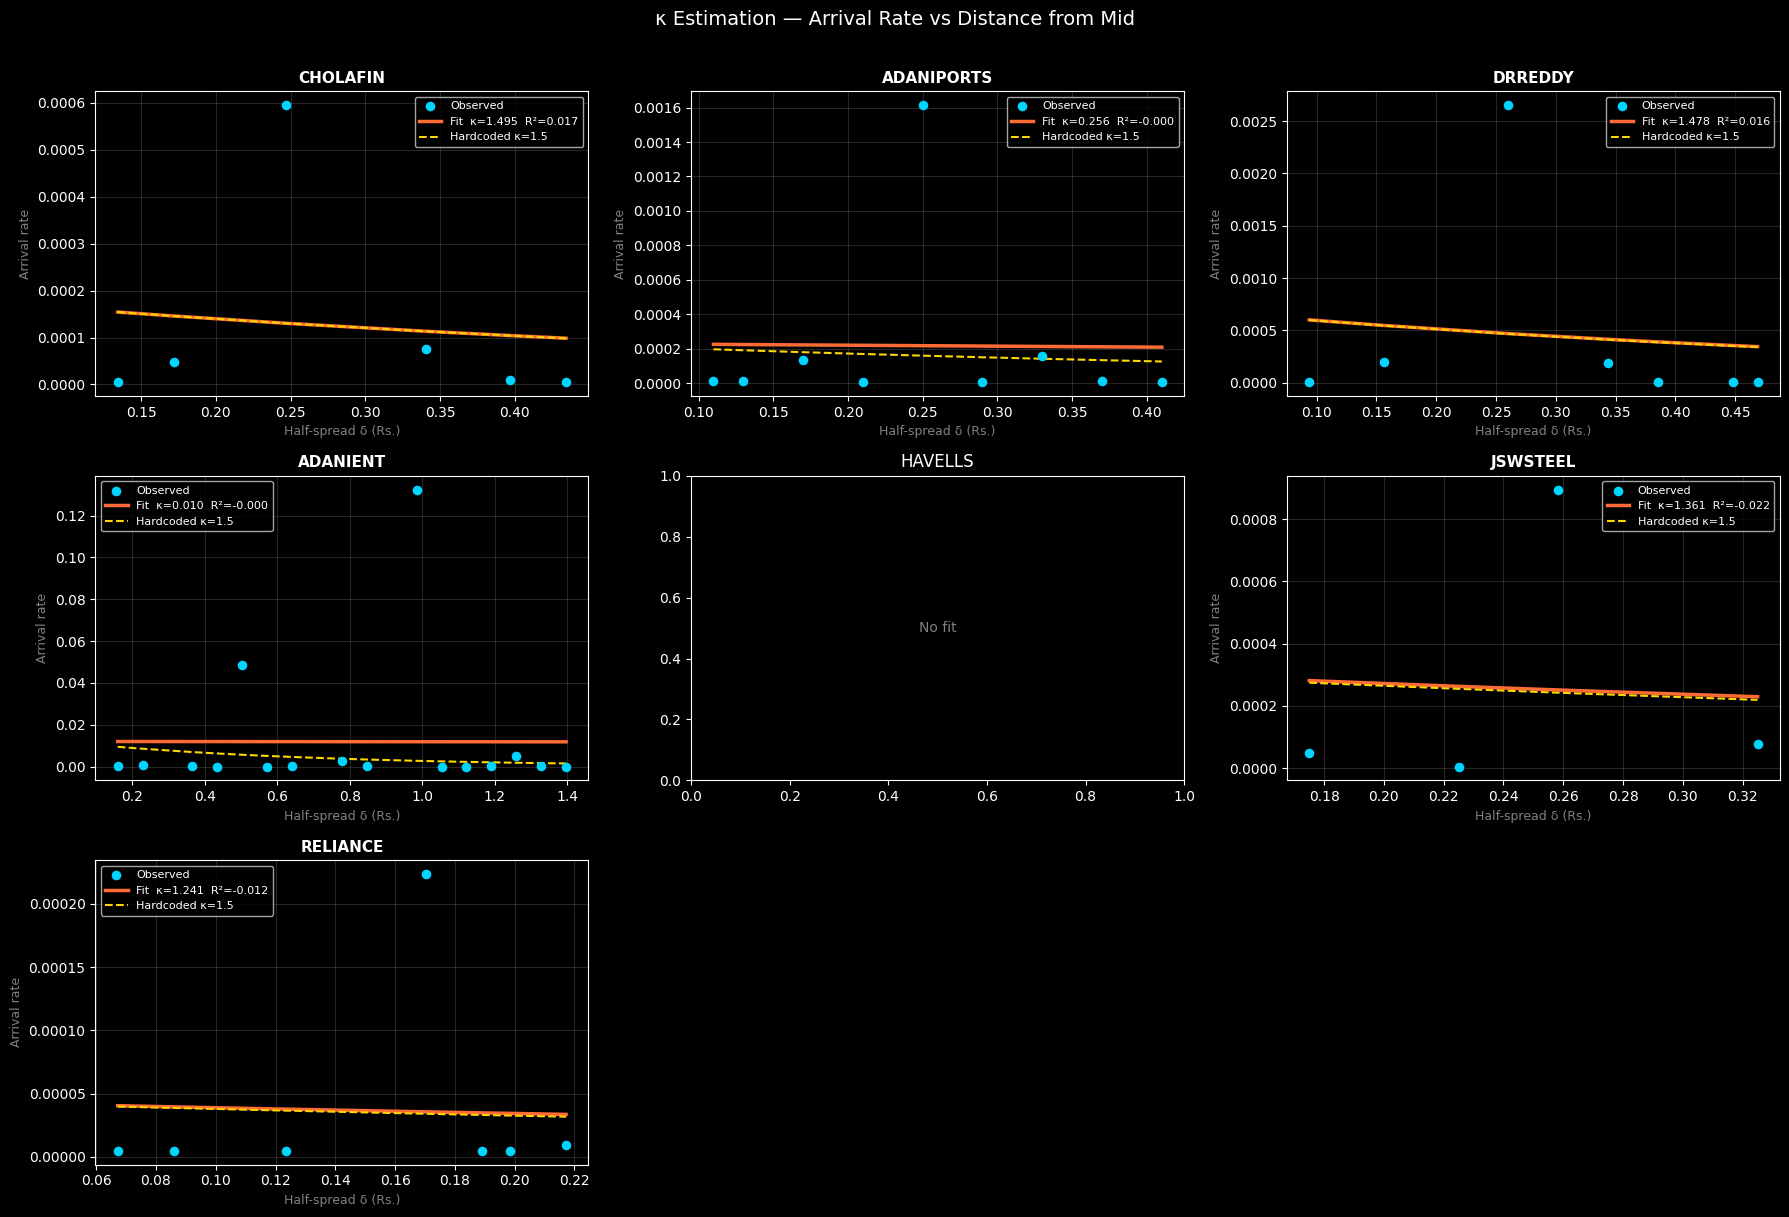

Saved: findings/kappa_fits.png


In [7]:
n = len(kappa_results)
cols = 3
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
axes = axes.flatten()

for i, (sym, res) in enumerate(kappa_results.items()):
    ax = axes[i]
    if np.isnan(res.get('kappa', np.nan)) or 'x_bins' not in res:
        ax.text(0.5, 0.5, 'No fit', ha='center', va='center',
                transform=ax.transAxes, color='gray')
        ax.set_title(sym.replace('26MAYFUT', ''), color='white')
        continue

    x, y, y_fit = res['x_bins'], res['y_rates'], res['y_fit']
    ax.scatter(x, y, color='#00d4ff', s=35, zorder=3, label='Observed')
    ax.plot(x, y_fit, color='#ff6b35', lw=2.5,
            label=f"Fit  κ={res['kappa']:.3f}  R²={res['r2']:.3f}")
    y_ref = res['A'] * np.exp(-1.5 * x)
    ax.plot(x, y_ref, color='#ffd700', lw=1.5, ls='--', label='Hardcoded κ=1.5')
    ax.set_title(sym.replace('26MAYFUT', ''), color='white', fontsize=11, fontweight='bold')
    ax.set_xlabel('Half-spread δ (Rs.)', color='gray', fontsize=9)
    ax.set_ylabel('Arrival rate', color='gray', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.15)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('κ Estimation — Arrival Rate vs Distance from Mid',
             fontsize=14, color='white', y=1.01)
plt.tight_layout()
plt.savefig('../findings/kappa_fits.png', dpi=150, bbox_inches='tight', facecolor='black')
plt.show()
print('Saved: findings/kappa_fits.png')

## 7. Time-of-Day Arrival Rate

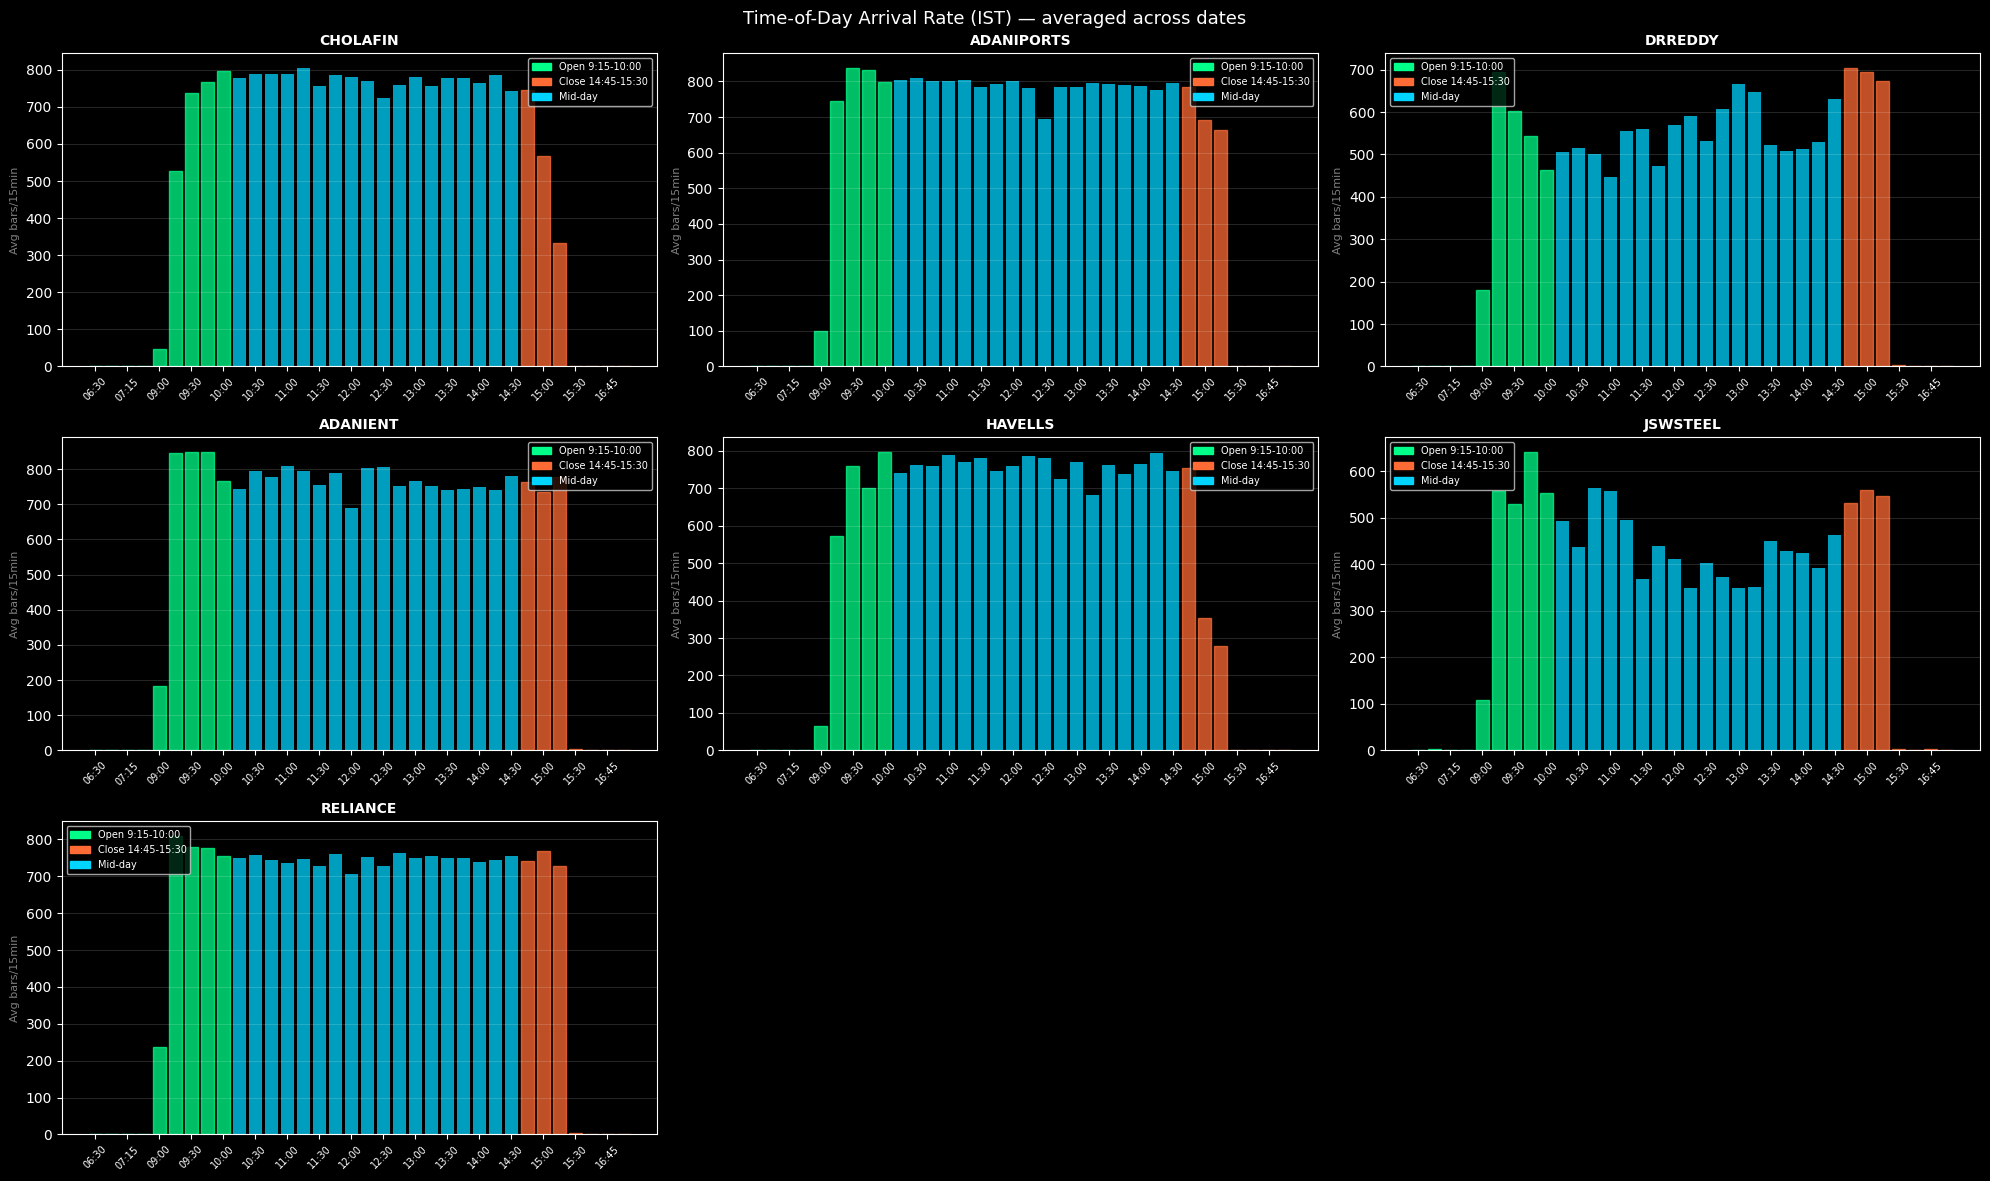

Saved: findings/tod_arrival_rates.png


In [8]:
def arrival_rate_by_time(df: pd.DataFrame, bucket_min: int = 15) -> pd.DataFrame:
    df2 = df.copy()
    bucket_sec    = bucket_min * 60
    df2['bucket'] = (df2['ist_tod_sec'] // bucket_sec) * bucket_sec
    df2['hhmm']   = df2['bucket'].apply(
        lambda s: f"{int(s)//3600:02d}:{(int(s)%3600)//60:02d}"
    )
    grouped = df2.groupby(['date', 'hhmm']).size().reset_index(name='count')
    return grouped.groupby('hhmm')['count'].mean().reset_index().sort_values('hhmm')


n = len(symbol_data)
cols = 3
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
axes = axes.flatten()

for i, (sym, df) in enumerate(symbol_data.items()):
    tod  = arrival_rate_by_time(df)
    ax   = axes[i]
    bars = ax.bar(range(len(tod)), tod['count'], color='#00d4ff', alpha=0.75, width=0.8)

    for bi, hhmm in enumerate(tod['hhmm']):
        if hhmm <= '10:00':
            bars[bi].set_color('#00ff88')
        elif hhmm >= '14:45':
            bars[bi].set_color('#ff6b35')

    ax.set_xticks(range(0, len(tod), 2))
    ax.set_xticklabels(tod['hhmm'].iloc[::2], rotation=45, fontsize=7)
    ax.set_title(sym.replace('26MAYFUT', ''), color='white', fontsize=10, fontweight='bold')
    ax.set_ylabel('Avg bars/15min', color='gray', fontsize=8)
    ax.grid(alpha=0.15, axis='y')
    ax.legend(handles=[
        Patch(color='#00ff88', label='Open 9:15-10:00'),
        Patch(color='#ff6b35', label='Close 14:45-15:30'),
        Patch(color='#00d4ff', label='Mid-day'),
    ], fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Time-of-Day Arrival Rate (IST) — averaged across dates',
             fontsize=13, color='white')
plt.tight_layout()
plt.savefig('../findings/tod_arrival_rates.png', dpi=150, bbox_inches='tight', facecolor='black')
plt.show()
print('Saved: findings/tod_arrival_rates.png')

## 8. Spread Distribution

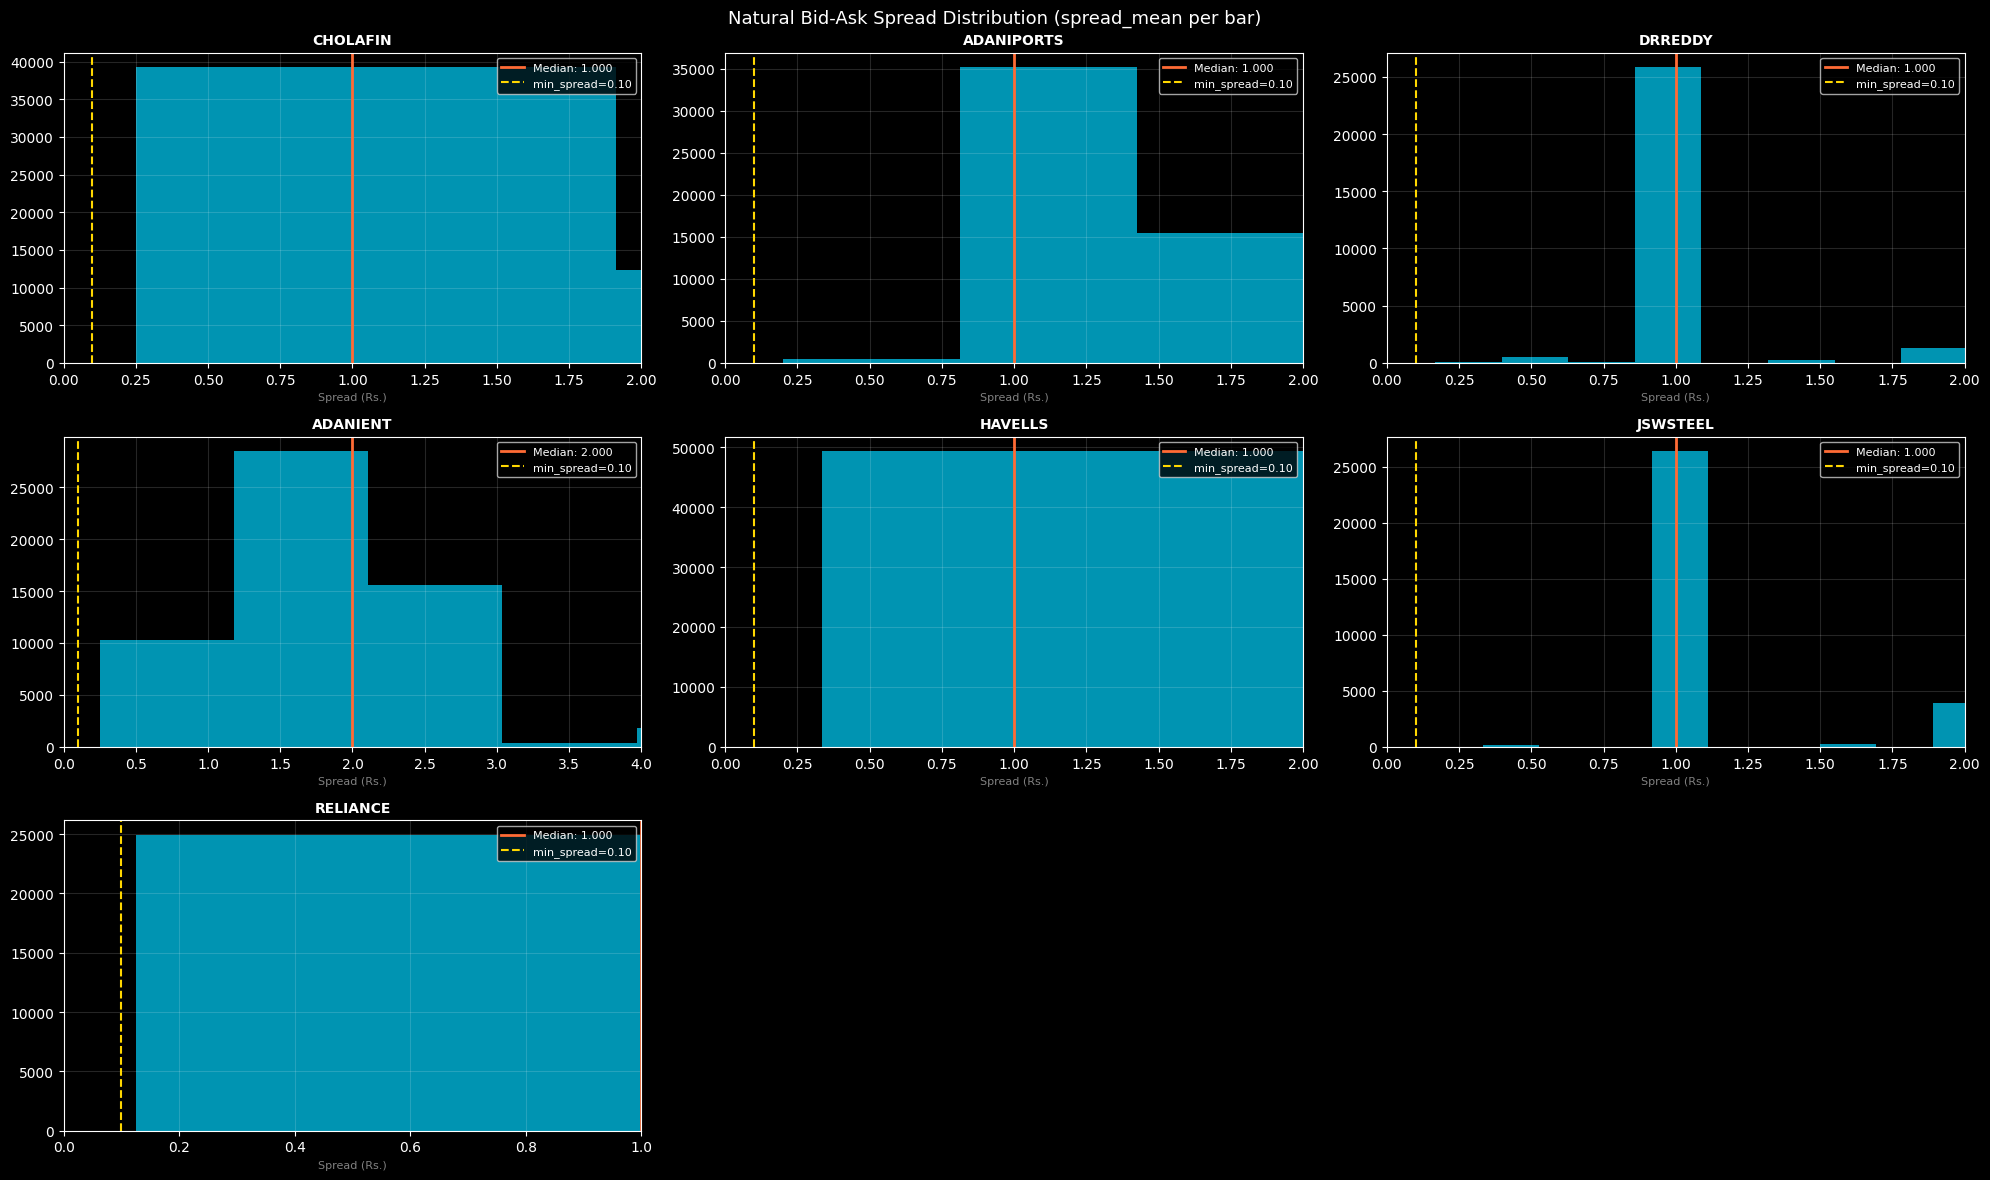


Symbol                             Median      P25      P75      Bps   min_spread OK?
--------------------------------------------------------------------------------------
CHOLAFIN26MAYFUT                   1.0000   1.0000   1.3333     6.38            ✓ YES
ADANIPORTS26MAYFUT                 1.0000   1.0000   2.0000     5.69            ✓ YES
DRREDDY26MAYFUT                    1.0000   1.0000   1.0000     7.58            ✓ YES
ADANIENT26MAYFUT                   2.0000   2.0000   3.0000     7.59            ✓ YES
HAVELLS26MAYFUT                    1.0000   1.0000   2.0000     8.33            ✓ YES
JSWSTEEL26MAYFUT                   1.0000   1.0000   1.0000     7.73            ✓ YES
RELIANCE26MAYFUT                   1.0000   1.0000   1.0000     0.00            ✓ YES


In [9]:
n = len(symbol_data)
cols = 3
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
axes = axes.flatten()

spread_stats = {}
for i, (sym, df) in enumerate(symbol_data.items()):
    sp  = df['spread_mean'].dropna()
    sp  = sp[sp > 0]
    bps = df['spread_bps'].dropna()

    spread_stats[sym] = {
        'median_spread':     round(float(sp.median()), 4),
        'p25_spread':        round(float(sp.quantile(0.25)), 4),
        'p75_spread':        round(float(sp.quantile(0.75)), 4),
        'median_spread_bps': round(float(bps.median()), 2),
        'min_spread_safe':   bool(sp.median() >= 0.10),
    }

    ax = axes[i]
    ax.hist(sp, bins=60, color='#00d4ff', alpha=0.7, edgecolor='none')
    ax.axvline(sp.median(), color='#ff6b35', lw=2, label=f'Median: {sp.median():.3f}')
    ax.axvline(0.10, color='#ffd700', lw=1.5, ls='--', label='min_spread=0.10')
    ax.set_xlim(0, sp.quantile(0.97))
    ax.set_title(sym.replace('26MAYFUT', ''), color='white', fontsize=10, fontweight='bold')
    ax.set_xlabel('Spread (Rs.)', color='gray', fontsize=8)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.15)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Natural Bid-Ask Spread Distribution (spread_mean per bar)',
             fontsize=13, color='white')
plt.tight_layout()
plt.savefig('../findings/spread_distributions.png', dpi=150, bbox_inches='tight', facecolor='black')
plt.show()

print(f"\n{'Symbol':30s} {'Median':>10} {'P25':>8} {'P75':>8} {'Bps':>8} {'min_spread OK?':>16}")
print('-' * 86)
for sym, s in spread_stats.items():
    ok = '✓ YES' if s['min_spread_safe'] else '✗ BELOW'
    print(f"{sym:30s} {s['median_spread']:>10.4f} {s['p25_spread']:>8.4f} "
          f"{s['p75_spread']:>8.4f} {s['median_spread_bps']:>8.2f} {ok:>16}")

## 9. Intraday Volatility Profile

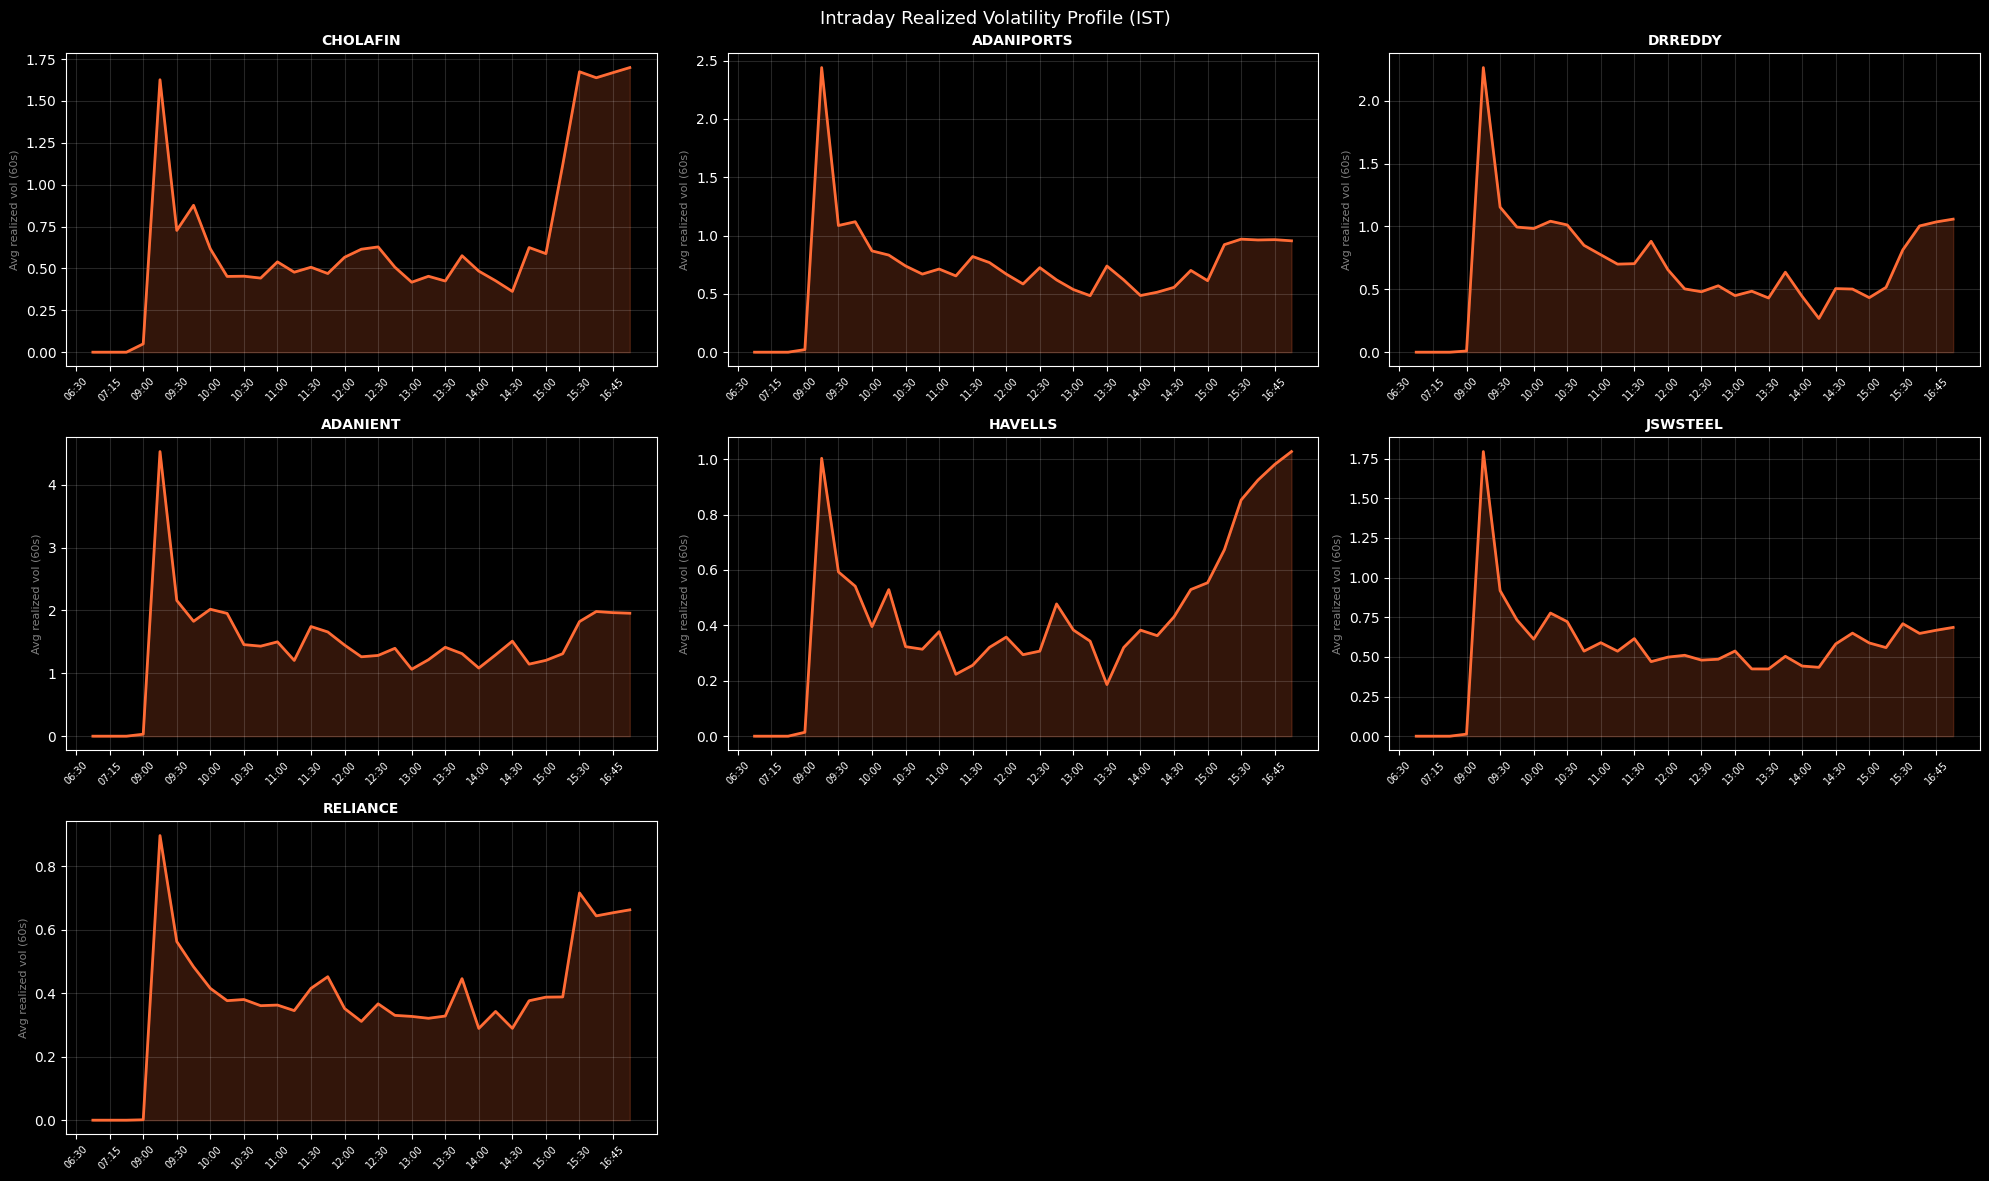

Saved: findings/vol_profiles.png


In [10]:
first_df = list(symbol_data.values())[0]
if 'realized_vol_60s' in first_df.columns:
    n = len(symbol_data)
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
    axes = axes.flatten()

    for i, (sym, df) in enumerate(symbol_data.items()):
        df2 = df.copy()
        df2['bucket'] = (df2['ist_tod_sec'] // 900) * 900
        df2['hhmm']   = df2['bucket'].apply(
            lambda s: f"{int(s)//3600:02d}:{(int(s)%3600)//60:02d}"
        )
        tod_vol = df2.groupby('hhmm')['realized_vol_60s'].mean()

        ax = axes[i]
        ax.plot(range(len(tod_vol)), tod_vol.values, color='#ff6b35', lw=2)
        ax.fill_between(range(len(tod_vol)), tod_vol.values, alpha=0.2, color='#ff6b35')
        ax.set_xticks(range(0, len(tod_vol), 2))
        ax.set_xticklabels(tod_vol.index[::2], rotation=45, fontsize=7)
        ax.set_title(sym.replace('26MAYFUT', ''), color='white', fontsize=10, fontweight='bold')
        ax.set_ylabel('Avg realized vol (60s)', color='gray', fontsize=8)
        ax.grid(alpha=0.15)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle('Intraday Realized Volatility Profile (IST)',
                 fontsize=13, color='white')
    plt.tight_layout()
    plt.savefig('../findings/vol_profiles.png', dpi=150, bbox_inches='tight', facecolor='black')
    plt.show()
    print('Saved: findings/vol_profiles.png')
else:
    print('realized_vol_60s not in columns — skipping. Available:', first_df.columns.tolist())

## 10. Save Findings

In [11]:
findings = {}
for sym in symbol_data:
    findings[sym] = {
        'kappa':             kappa_results[sym].get('kappa'),
        'kappa_A':           kappa_results[sym].get('A'),
        'kappa_r2':          kappa_results[sym].get('r2'),
        'lambda_per_min':    iat_stats[sym].get('lambda_per_min'),
        'mean_iat_sec':      iat_stats[sym].get('mean_iat_sec'),
        'is_poisson':        iat_stats[sym].get('is_poisson'),
        'ks_pval':           iat_stats[sym].get('ks_pval'),
        'median_spread':     spread_stats[sym].get('median_spread'),
        'p25_spread':        spread_stats[sym].get('p25_spread'),
        'p75_spread':        spread_stats[sym].get('p75_spread'),
        'median_spread_bps': spread_stats[sym].get('median_spread_bps'),
        'min_spread_safe':   spread_stats[sym].get('min_spread_safe'),
        'n_bars':            iat_stats[sym].get('n_bars'),
        'dates_used':        DATES,
        'calibrated_at':     datetime.now().isoformat(),
    }

output_path = os.path.join(FINDINGS_DIR, 'kappa_by_symbol.json')
with open(output_path, 'w') as f:
    json.dump(findings, f, indent=2, default=str)

print(f'Saved → {output_path}\n')
print(f"{'Symbol':30s} {'κ real':>10} {'κ=1.5 Δ':>10} {'spread OK':>12}")
print('-' * 68)
for sym, f_ in findings.items():
    k  = f_['kappa']
    ok = '✓' if f_.get('min_spread_safe') else '✗'
    if k is not None and not (isinstance(k, float) and np.isnan(k)):
        print(f"{sym:30s} {k:>10.4f} {k-1.5:>+10.4f} {ok:>12}")
    else:
        print(f"{sym:30s} {'N/A':>10} {'N/A':>10} {ok:>12}")

Saved → ../findings\kappa_by_symbol.json

Symbol                             κ real    κ=1.5 Δ    spread OK
--------------------------------------------------------------------
CHOLAFIN26MAYFUT                   1.4953    -0.0047            ✓
ADANIPORTS26MAYFUT                 0.2564    -1.2436            ✓
DRREDDY26MAYFUT                    1.4779    -0.0221            ✓
ADANIENT26MAYFUT                   0.0100    -1.4900            ✓
HAVELLS26MAYFUT                       N/A        N/A            ✓
JSWSTEEL26MAYFUT                   1.3614    -0.1386            ✓
RELIANCE26MAYFUT                   1.2414    -0.2586            ✓


## 11. Integration into mm_strategy.py

In [12]:
print('''
Add to src/backtest/mm_strategy.py:

import json
from pathlib import Path

_KAPPA_PATH  = Path(__file__).resolve().parents[2] / "research" / "findings" / "kappa_by_symbol.json"
_KAPPA_TABLE = json.loads(_KAPPA_PATH.read_text()) if _KAPPA_PATH.exists() else {}

# In MMStrategy.__init__, replace hardcoded kappa with:
self.kappa = _KAPPA_TABLE.get(symbol, {}).get('kappa') or kappa
''')


Add to src/backtest/mm_strategy.py:

import json
from pathlib import Path

_KAPPA_PATH  = Path(__file__).resolve().parents[2] / "research" / "findings" / "kappa_by_symbol.json"
_KAPPA_TABLE = json.loads(_KAPPA_PATH.read_text()) if _KAPPA_PATH.exists() else {}

# In MMStrategy.__init__, replace hardcoded kappa with:
self.kappa = _KAPPA_TABLE.get(symbol, {}).get('kappa') or kappa



## 12. Conclusions

*(Fill in after running)*

### Key Questions
1. Which symbols have κ significantly ≠ 1.5?
2. Is order flow Poisson for all symbols? (non-Poisson → Hawkes process, Year 2)
3. Which time windows have peak arrival rates? (validates time-of-day filter)
4. Is `min_spread=0.10` below median natural spread for all symbols?
5. Which symbols have highest intraday vol → need widest dynamic spreads?

### Action Items
- [ ] Integrate calibrated κ into `mm_strategy.py`
- [ ] Re-run `backtest_all_futures.py` with calibrated κ, compare vs κ=1.5
- [ ] Re-run notebook monthly as data accumulates
- [ ] Next: `02_realized_volatility.ipynb` — dynamic σ estimation